# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [3]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [4]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Split into features and target (optional)
X = data.drop("MEDV", axis=1)  # Predictor variables
y = data["MEDV"]               # Target variable

# Create 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (404, 13)
Testing set shape: (102, 13)


## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [7]:
from sklearn.linear_model import LinearRegression

# 1. Create the model
model = LinearRegression()

# 2. Train on the training set
model.fit(X_train, y_train)

print("Model trained!")

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# View a few predictions
print("Training Predictions:")
print(train_predictions[:5])

print("\nTesting Predictions:")
print(test_predictions[:5])

Model trained!
Training Predictions:
[10.96952405 19.41196567 23.06419602 12.1470648  18.3738116 ]

Testing Predictions:
[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]


## 3. Calculate and print R-squared for both the training and the testing set.

In [8]:
from sklearn.metrics import r2_score

y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)

print(f"R² (train set): {r2_train:.4f}")
print(f"R² (test set): {r2_test:.4f}")

R² (train set): 0.7509
R² (test set): 0.6688


## 4. Calculate and print mean squared error for both the training and the testing set.

In [9]:
from sklearn.metrics import mean_squared_error

# MSE: average of squared errors
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"MSE train: {mse_train:.4f}")
print(f"MSE test: {mse_test:.4f}")

MSE train: 21.6414
MSE test: 24.2911


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [10]:
from sklearn.metrics import mean_absolute_error

# MAE: average of absolute errors
mae = mean_absolute_error(y_test, y_test_pred)

print(f"MAE: {mae:.4f}")
print(f"  → On average, predictions are off by ${mae * 100_000:,.0f}")

MAE: 3.1891
  → On average, predictions are off by $318,909


## Classification Model Evaluation

In [21]:
from sklearn.datasets import load_iris
data = load_iris()

In [22]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [23]:
column_names = data.feature_names

In [24]:
df = pd.DataFrame(data['data'],columns=column_names)

In [25]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [26]:
target = pd.DataFrame(data.target)

In [27]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [28]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [33]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = data.data
y = data.target

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # preserves class proportions
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Training set size: (120, 4)
Testing set size: (30, 4)


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✅")

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# View a few predictions
print("Training Predictions:")
print(y_train_pred[:5])

print("\nTesting Predictions:")
print(y_test_pred[:5])

Model trained ✅
Training Predictions:
[0 1 1 0 1]

Testing Predictions:
[0 2 1 1 0]


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [35]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {acc_train:.2%}")
print(f"Test Accuracy: {acc_test:.2%}")

Training Accuracy: 97.50%
Test Accuracy: 96.67%


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [49]:
from sklearn.metrics import balanced_accuracy_score

# Balanced accuracy on training set
train_bal_acc = balanced_accuracy_score(y_train, y_train_pred)

# Balanced accuracy on testing set
test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"Training Balanced Accuracy: {train_bal_acc:.4f}")
print(f"Testing Balanced Accuracy:  {test_bal_acc:.4f}")

Training Balanced Accuracy: 0.9750
Testing Balanced Accuracy:  0.9667


## 10. Calculate and print the precision score for both the training and the testing set.

In [50]:
from sklearn.metrics import precision_score

# Precision on training set
train_precision = precision_score(
    y_train,
    y_train_pred,
    average='macro'
)

# Precision on testing set
test_precision = precision_score(
    y_test,
    y_test_pred,
    average='macro'
)

print(f"Training Precision (Macro): {train_precision:.4f}")
print(f"Testing Precision (Macro):  {test_precision:.4f}")

Training Precision (Macro): 0.9752
Testing Precision (Macro):  0.9697


## 11. Calculate and print the recall score for both the training and the testing set.

In [51]:
from sklearn.metrics import recall_score

# Recall on training set
train_recall = recall_score(
    y_train,
    y_train_pred,
    average='macro'
)

# Recall on testing set
test_recall = recall_score(
    y_test,
    y_test_pred,
    average='macro'
)

print(f"Training Recall (Macro): {train_recall:.4f}")
print(f"Testing Recall (Macro):  {test_recall:.4f}")

Training Recall (Macro): 0.9750
Testing Recall (Macro):  0.9667


## 12. Calculate and print the F1 score for both the training and the testing set.

In [52]:
from sklearn.metrics import f1_score

# F1 score on training set
train_f1 = f1_score(
    y_train,
    y_train_pred,
    average='macro'
)

# F1 score on testing set
test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='macro'
)

print(f"Training F1 Score (Macro): {train_f1:.4f}")
print(f"Testing F1 Score (Macro):  {test_f1:.4f}")


Training F1 Score (Macro): 0.9750
Testing F1 Score (Macro):  0.9666


## 13. Generate confusion matrices for both the training and the testing set.

Training Confusion Matrix:
[[40  0  0]
 [ 0 38  2]
 [ 0  1 39]]

Testing Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


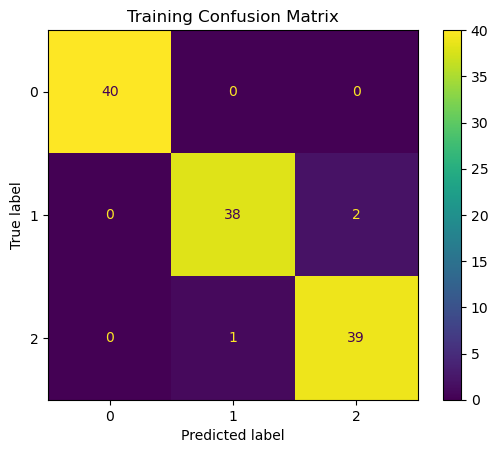

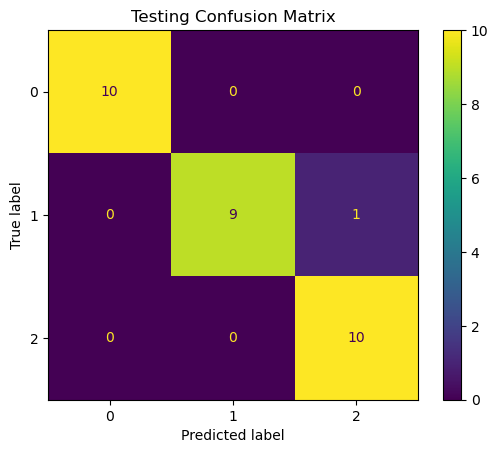

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("Training Confusion Matrix:")
print(cm_train)

print("\nTesting Confusion Matrix:")
print(cm_test)

# Plot training confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_train).plot()
plt.title("Training Confusion Matrix")
plt.show()

# Plot testing confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_test).plot()
plt.title("Testing Confusion Matrix")
plt.show()

## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

Training Confusion Matrix:
[[40  0  0]
 [ 0 40  0]
 [ 0  0 40]]

Testing Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


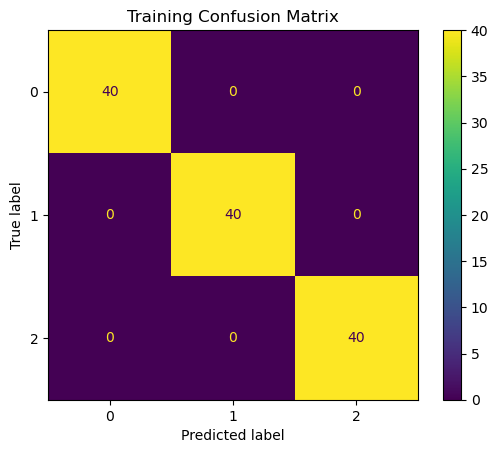

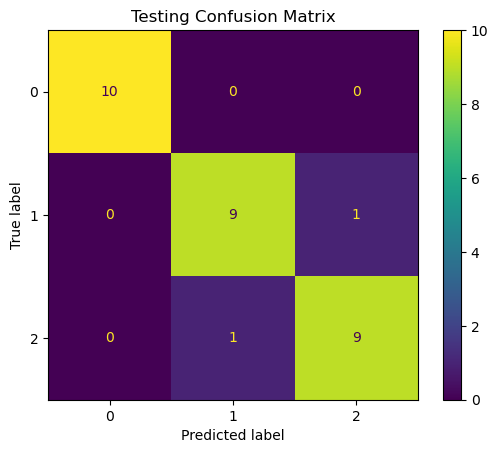

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Confusion matrices
cm_train = confusion_matrix(y_train, train_pred)
cm_test = confusion_matrix(y_test, test_pred)

print("Training Confusion Matrix:")
print(cm_train)

print("\nTesting Confusion Matrix:")
print(cm_test)

# Plot training confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_train).plot()
plt.title("Training Confusion Matrix")
plt.show()

# Plot testing confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_test).plot()
plt.title("Testing Confusion Matrix")
plt.show()